In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

## Dataset
Let's suppose we have following training dataset
* The input variable `X` is a numpy array has 6 training examples, each with two features
* The output variable `y` is also a numpy array with 6 training examples, and `y` is either `0` or `1`

In [9]:
X = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1, 1)

In [10]:
def plot_data(X, y, ax, pos_label = "y=1", neg_label="y=0", s=80, loc='best'): 
    pos = (y == 1)
    neg = (y == 0)
    pos = pos.reshape(-1,) 
    neg = neg.reshape(-1,) 

    ax.scatter(X[pos, 0], X[pos, 1], s=s, color='r', label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], s=s, color='b', label=neg_label)
    ax.legend(loc=loc)

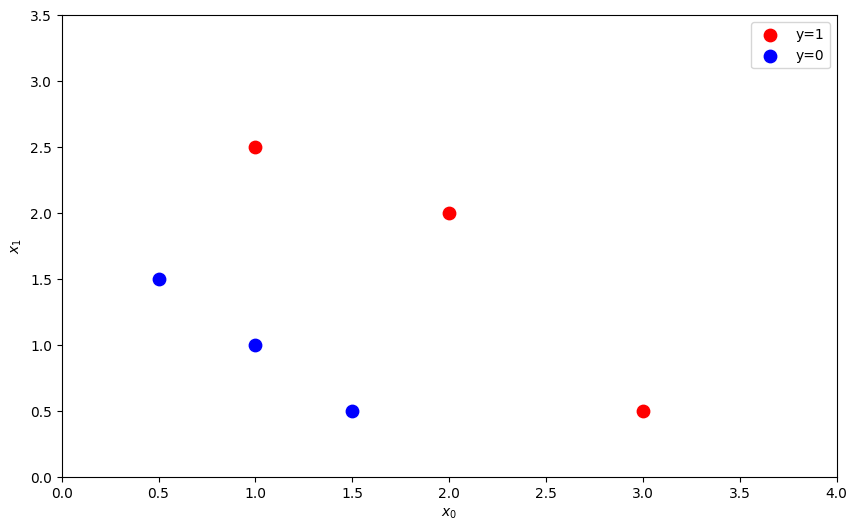

In [13]:
fig, ax=plt.subplots(1, 1, figsize=(10, 6)) 
plot_data(X, y, ax)
ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$') 
ax.set_xlabel('$x_0$') 
plt.show()

## Logistic regression model 
* Suppose you'd like to train a logistic regression model on this data which has the form $f(x) = g(w_0x_0 + w_1x_1 + b)$
where $g(z) = \frac{1}{1 + e^{-z}}$, which is the sigmoid function
* Let's say that you trained the model and get the parameters as $b = -3$, $w_0 = 1$, $w_1 = 1$. That is,
$f(x) = g(x_0 + x_1 - 3)$

* Recall that for logistic regression, the model is represented as
$$f_{w, b}(\mathbf{x}^{(i}) = g(\mathbf{w}\cdot\mathbf{x}^{(i)} + b)$$
where g(z) is known as the sigmoid function and it maps all input values to values between 0 and 1:
$$g(z) = \frac{1}{1 + e^{-z}}$$
and $\mathbf{w}\cdot\mathbf{x}$ is the vector dot product
$$\mathbf{w}\cdot\mathbf{x} = w_0x_0 + w_1x_1$$
* We interpret the output of the model $f_{w, b}(x)$ as the probability that y = 1 given $\mathbf{x}$ and parameterized by $\mathbf{w}$ and b.
  * Therefore, to get a final prediction ($y = 0$ or $y = 1$) from the logistic regression model, we can use the following heuristic

If $f_{w, b}(x) \geq 0.5$, predict $y = 1$

If $f_{w, b}(x) < 0.5$, predict $y = 0$

* Let's plot the sigmoid function to see where $g(z) \geq 0.5$

In [18]:
def sigmoid(z): 
    return 1/(1 + np.exp(-z))

Text(0.5, 0, 'z')

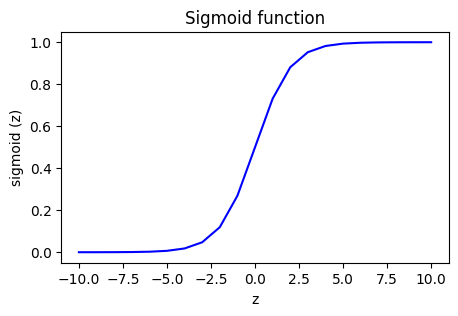

In [19]:
z = np.arange(-10, 11) 

fig, ax = plt.subplots(1, 1, figsize=(5, 3)) 
ax.plot(z, sigmoid(z), c='b') 

ax.set_title("Sigmoid function") 
ax.set_ylabel('sigmoid (z)') 
ax.set_xlabel('z') 

* As we can see, $g(z) \geq 0.5$ for $z \geq 0$
* For a logistic regression model, $z = \mathbf{w}\cdot\mathbf{x} + b$. Therefore,

if $\mathbf{w}\cdot\mathbf{x} + b \geq 0$, the model predicts $y = 1$

if $\mathbf{w}\cdot\mathbf{x} + b < 0$, the model predicts $y = 0$

## Plotting decision boundary 
* Our logistic regression model has the form

$f(\mathbf{x}) = g(-3 + x_0 + x_1)$
* From what we've learned above, we can see that this model predicts $y = 1$ if $-3 + x_0 + x_1 \geq 0$

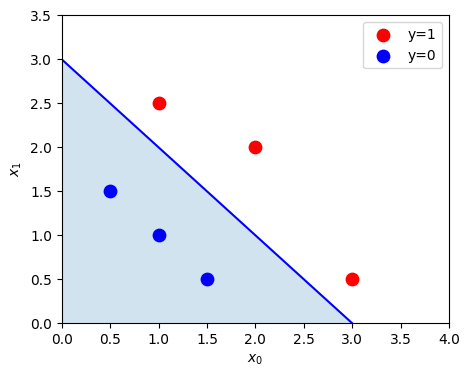

In [29]:
x0 = np.arange(0, 6) 
x1 = 3 - x0 
fig, ax= plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x0, x1, c="b") 
ax.axis([0, 4, 0, 3.5])

ax.fill_between(x0, x1, alpha=0.2) 

plot_data(X, y, ax) 
ax.set_ylabel(r'$x_1$') 
ax.set_xlabel(r'$x_0$') 
plt.show()

* In the plot above, the blue line represents the line $x_0 + x_1 - 3 = 0$ and it should intersect the x1 axis at 3 (if we set $x_1 = 3, x_0 = 0$ and $x_0$ axis at 3 (if we set $x_1 = 0, x_0 = 3$)
* The shaded region represents $-3 + x_0 + x_1 < 0$. The region above the line is $-3 + x_0 + x_1 > 0$
* Any point in the shaded region is classified as $y = 0$. Any point on or above the line is classified as $y = 1$. This decision is known as the "decision boundary".